# University Program Skill Analysis with LAiSER

This notebook provides a quick overview of skills taught across various university programs by extracting and categorizing skills from their descriptions.

- Author: Satya Phanindra Kumar Kalaga
- Date: September 2025

## 1. Setup

First, let's install the `laiser` package and other necessary libraries.

In [ ]:
!pip install laiser pandas matplotlib seaborn torch

## 2. Import Libraries

In [ ]:
import torch
import pandas as pd
from laiser.skill_extractor_refactored import SkillExtractorRefactored
import matplotlib.pyplot as plt
import seaborn as sns

/usr/local/lib/python3.12/dist-packages/laiser/llm_models/__init__.py:16: UserWarning: Some LLM model dependencies are not available: cannot import name 'GeminiAPI' from 'laiser.llm_models.gemini' (/usr/local/lib/python3.12/dist-packages/laiser/llm_models/gemini.py)
  warnings.warn(f"Some LLM model dependencies are not available: {e}")


## 3. Initialize the Skill Extractor

We'll initialize the `SkillExtractorRefactored`. Remember to replace `"your_model_id"` and `"your_hf_token"` with your actual Hugging Face credentials.

In [ ]:
# Replace with your Hugging Face model ID and token
model_id = "gemini"  # e.g., "mistralai/Mistral-7B-Instruct-v0.1"
api_key = "Your-key"

try:
    se = SkillExtractorRefactored(model_id=model_id, api_key=api_key, use_gpu=False)
    print("Skill Extractor initialized successfully!")
except Exception as e:
    print(f"Error initializing Skill Extractor: {e}")

Using Gemini API for skill extraction...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Skill Extractor initialized successfully!


## 4. Load Program Description Data

We will load a sample dataset of university program descriptions. This dataset will serve as our source for skill extraction. For this example, we'll create a sample DataFrame.

In [ ]:
# Sample data representing university programs
data = {
    'program_id': [101, 102, 103, 104],
    'program_name': ['Computer Science', 'Data Science', 'Business Analytics', 'Mechanical Engineering'],
    'description': [
        'Our Computer Science program focuses on software development, algorithms, and data structures. Students will learn Python, Java, and C++.',
        'The Data Science program teaches students to analyze large datasets. Key topics include machine learning, statistical modeling, and data visualization using R and Python.',
        'The Business Analytics program bridges the gap between data and decision-making. Students learn SQL, Tableau, and business intelligence techniques.',
        'Our Mechanical Engineering program covers thermodynamics, fluid mechanics, and robotics. Students gain hands-on experience with CAD software and 3D printing.'
    ]
}
program_data = pd.DataFrame(data)
print("Program data loaded successfully:")
program_data

Program data loaded successfully:


,program_id,program_name,description
0,101,Computer Science,Our Computer Science program focuses on softwa...
1,102,Data Science,The Data Science program teaches students to a...
2,103,Business Analytics,The Business Analytics program bridges the gap...
3,104,Mechanical Engineering,Our Mechanical Engineering program covers ther...


## 5. Extract Skills from Program Descriptions

Now we'll use the `extract_and_align` method to get the skills from the program descriptions.

In [ ]:
try:
    extracted_skills = se.extract_and_align(
        program_data,
        id_column="program_id",
        text_columns=["description"],
        input_type='syllabus'  # Using 'syllabus' as the input type for program descriptions
    )
    print("Skills extracted successfully!")
    print(extracted_skills.head())
except Exception as e:
    print(f"Error during skill extraction: {e}")

Skills extracted successfully!
  Research ID             Raw Skill                   Taxonomy Skill  \
0         101  software development  oversee development of software   
1         101            algorithms             Algorithmic software   
2         101       data structures   Structured data entry software   
3         101                Python                           Python   
4         101                  Java            Sun Microsystems Java   

                                Taxonomy Description Taxonomy Source  \
0  Organise, plan and supervise the development o...            esco   
1  Algorithmic software (Analytical or scientific...       onet_tech   
2  Structured data entry software (Data base user...       onet_tech   
3  Python (Object or component oriented developme...       onet_tech   
4  Sun Microsystems Java (Object or component ori...       onet_tech   

   Correlation Coefficient  
0                 0.659541  
1                 0.557399  
2               

## 6. Categorize and Visualize Skills

To get a better overview, we'll merge the extracted skills with the program names and then visualize the distribution of skills across different programs.

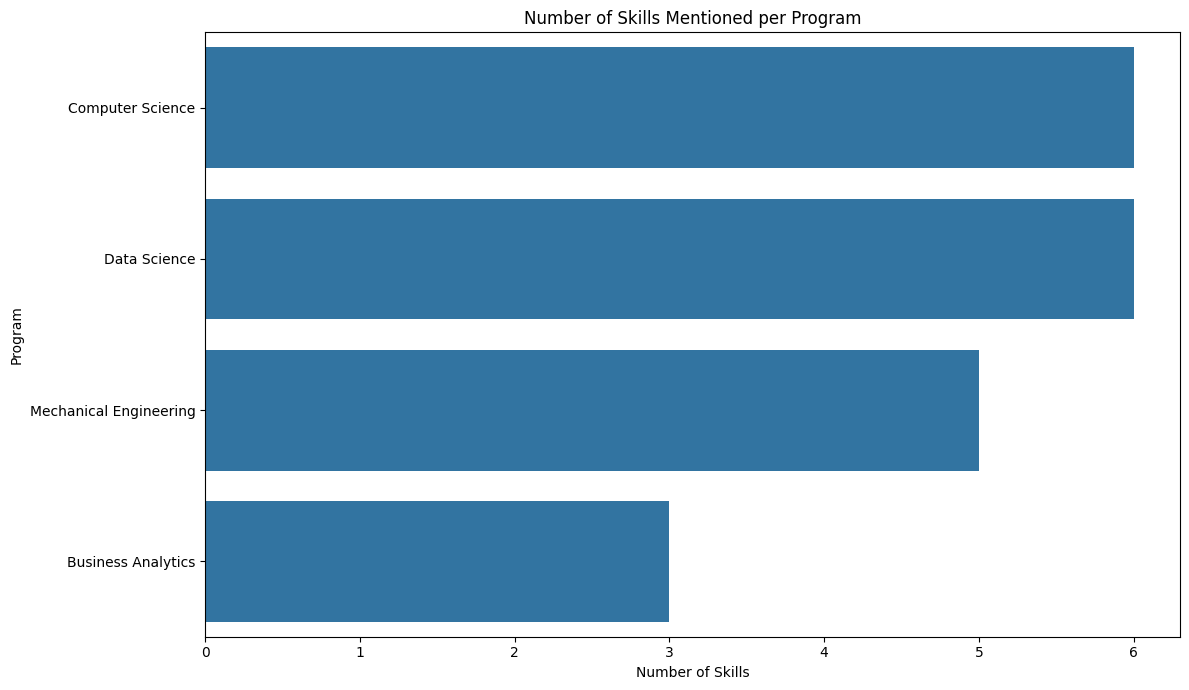

--- Skills for Computer Science ---
software development, algorithms, data structures, Python, Java, C++


--- Skills for Data Science ---
analyze large datasets, machine learning, statistical modeling, data visualization, R, Python


--- Skills for Business Analytics ---
SQL, Tableau, business intelligence techniques


--- Skills for Mechanical Engineering ---
thermodynamics, fluid mechanics, robotics, CAD software, 3D printing




In [ ]:
if 'extracted_skills' in locals() and not extracted_skills.empty:
    # Cast Research ID to integer to match program_id
    extracted_skills['Research ID'] = extracted_skills['Research ID'].astype(int)
    # Merge with original data to get program names
    skills_with_programs = pd.merge(extracted_skills, program_data[['program_id', 'program_name']], left_on='Research ID', right_on='program_id')

    # Plot the number of skills per program
    plt.figure(figsize=(12, 7))
    sns.countplot(y='program_name', data=skills_with_programs, order=skills_with_programs['program_name'].value_counts().index)
    plt.title('Number of Skills Mentioned per Program')
    plt.xlabel('Number of Skills')
    plt.ylabel('Program')
    plt.tight_layout()
    plt.show()

    # Show a table of skills for each program
    for program in skills_with_programs['program_name'].unique():
        print(f"--- Skills for {program} ---")
        # Using 'Raw Skill' from the extracted skills
        skills_list = skills_with_programs[skills_with_programs['program_name'] == program]['Raw Skill'].tolist()
        print(", ".join(skills_list))
        print("\n")
else:
    print("No skills were extracted to visualize.")